# Analisando Acidentes

Este documento descreve o processo técnico de organização e análise dos dados do RENAEST. O objetivo é compartilhar não apenas os resultados sobre segurança nas estradas, mas também o método utilizado para lidar com grandes volumes de dados de forma eficiente.

---

Configuração do notebook e importações

In [ ]:
from src.tools import *

---

## 1. O Desafio dos Dados Brutos

Trabalhar com o registro nacional de acidentes significa lidar com uma base que supera os 5 GB de informações. Quando os dados chegam até nós, eles estão em formato CSV, que é um formato de texto simples.

Embora o CSV seja fácil de ler por humanos, ele é ineficiente para processamento em larga escala, pois o computador precisa ler o arquivo linha por linha, do início ao fim, mesmo que queiramos saber apenas uma informação específica, como o "dia da semana".

## 2. Organização da Estrutura

Para gerenciar esse volume sem travar o processamento, organizei o projeto em três etapas lógicas no ambiente de nuvem (AWS S3 e Athena):

- **Camada Bronze:**
   Aqui, os arquivos CSV originais (Acidentes, Localidade, Veículos e Vítimas) são armazenados no Amazon S3. Guardando o dado bruto exatamente como ele foi gerado, assim obtendo garantia de que a fonte original está preservada.

- **Camada Prata:**
  Nesta etapa, conectamos o AWS Athena aos arquivos CSV da camada Bronze. Criamos tabelas que "espelham" o conteúdo dos arquivos. É aqui que definimos o que é cada coluna (números, textos, datas) e tratamos os erros de leitura, como campos vazios ou formatos inválidos. A partir daqui, já conseguimos fazer pesquisas usando SQL, embora a leitura do CSV ainda seja lenta pelo volume de dados.

  Exemplo:

  ```sql
    CREATE EXTERNAL TABLE IF NOT EXISTS `renasest`.`veiculos`(
      `num_acidente` BIGINT,
      `tipo_veiculo` STRING,
      `ind_veic_estrangeiro` STRING,
      `qtde_veiculos` BIGINT
    )
    ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
    WITH SERDEPROPERTIES (
      'separatorChar' = ';', 
      'quoteChar' = '"',
      'escapeChar' = '\\'
    )
    STORED AS TEXTFILE
    LOCATION 's3://r7melo-renasest-data/TipoVeiculo/'
    TBLPROPERTIES ('skip.header.line.count'='1');
    
  ```
  
- **Camada Gold:**
  Esta é a camada final e a mais importante para a performance. Criamos novas tabelas a partir da camada Prata, mas salvando os dados no formato Parquet. Ao contrário do CSV, o formato Gold organiza os dados de forma colunar e cria uma espécie de indexação automática. Isso permite que o sistema encontre informações específicas sem precisar ler o arquivo inteiro. O resultado é uma pesquisa muito mais veloz, transformando uma consulta de minutos em algo de poucos segundos.

  Exemplo:

  ```sql
    CREATE TABLE "renasest"."veiculos_gold"
    WITH (format = 'PARQUET', external_location = 's3://r7melo-renasest-views/gold_veiculos/')
    AS SELECT * FROM "renasest"."veiculos";

  ```


## 3. Sobre os Dados

Esta seção descreve as principais tabelas utilizadas na análise de acidentes de trânsito:

### Tabela de Vítimas

Esta tabela armazena informações demográficas, comportamentais e de gravidade relacionadas às vítimas envolvidas em cada acidente.

- **num_acidente**: Identificador único do acidente ao qual a vítima está associada.  
- **chv_localidade**: Chave de referência da localidade do acidente.  
- **data_acidente**: Data em que ocorreu o acidente.  
- **uf_acidente**: Unidade da Federação onde o acidente aconteceu.  
- **ano_acidente**: Ano de ocorrência do acidente.  
- **mes_acidente**: Mês de ocorrência do acidente (valor numérico).  
- **mes_ano_acidente**: Representação agregada de mês e ano do acidente (ex.: 2023-05).  

- **faixa_idade**: Classificação etária da vítima em faixas predefinidas.  
- **genero**: Sexo biológico da vítima.  
- **tp_envolvido**: Tipo de envolvimento da vítima no acidente (condutor, passageiro, pedestre, etc.).  
- **ind_motorista**: Indicador se a vítima era motorista (Sim/Não).  

- **gravidade_lesao**: Grau de severidade das lesões sofridas (Ileso, Ferido Leve, Ferido Grave, Óbito).  
- **equip_seguranca**: Indicação do uso de equipamento de segurança (cinto, capacete, cadeirinha).  
- **susp_alcool**: Indicador de suspeita de consumo de álcool (Sim/Não).  

- **qtde_envolvidos**: Quantidade total de pessoas envolvidas no acidente.  
- **qtde_feridosilesos**: Quantidade de vítimas classificadas como feridas ou ilesas.  
- **qtde_obitos**: Quantidade de óbitos registrados na ocorrência.

### Tabela de Veículos

Esta tabela descreve as características dos veículos envolvidos em cada ocorrência.

- **num_acidente**: Identificador único do acidente associado ao veículo.  
- **tipo_veiculo**: Categoria do veículo envolvido (Automóvel, Motocicleta, Caminhão, Ônibus, etc.).  
- **ind_veic_estrangeiro**: Indicador se o veículo possui registro estrangeiro (Sim/Não).  
- **qtde_veiculos**: Quantidade total de veículos envolvidos na ocorrência.

### Tabela de Localidade

Esta tabela contém informações geográficas, administrativas e estruturais da localidade do acidente.

- **chv_localidade**: Chave única de identificação da localidade.  
- **ano_referencia**: Ano de referência das informações da localidade.  
- **mes_referencia**: Mês de referência das informações (valor numérico).  
- **mes_ano_referencia**: Representação agregada de mês e ano de referência (ex.: 2023-05).  
- **regiao**: Região geográfica do Brasil (Norte, Nordeste, Sudeste, Sul, Centro-Oeste).  
- **uf**: Unidade da Federação.  
- **codigo_ibge**: Código IBGE do município.  
- **municipio**: Nome do município.  
- **regiao_metropolitana**: Indicação se o município pertence a uma região metropolitana.  
- **qtde_habitantes**: Quantidade de habitantes do município (Censo 2022).  
- **frota_total**: Quantidade total de veículos registrados no município.  
- **frota_circulante**: Quantidade estimada de veículos em circulação no município.

### Tabela de Acidentes

Esta tabela reúne informações temporais, ambientais e operacionais do acidente.

- **num_acidente**: Identificador único do acidente.  
- **chv_localidade**: Chave de referência da localidade onde ocorreu o acidente.  
- **data_acidente**: Data em que o acidente ocorreu.  
- **uf_acidente**: Unidade da Federação onde o acidente aconteceu.  
- **ano_acidente**: Ano de ocorrência do acidente.  
- **mes_acidente**: Mês de ocorrência do acidente (valor numérico).  
- **mes_ano_acidente**: Representação agregada de mês e ano do acidente (ex.: 2023-05).  
- **codigo_ibge**: Código IBGE do município da ocorrência.  
- **dia_semana**: Dia da semana em que ocorreu o acidente.  
- **fase_dia**: Classificação do período do dia (Amanhecer, Pleno dia, Anoitecer, Plena noite).  
- **tp_acidente**: Tipo do acidente (colisão, atropelamento, capotamento, etc.).  
- **cond_meteorologica**: Condição climática no momento do acidente (Céu Limpo, Chuva, Nublado, etc.).  
- **end_acidente**: Endereço ou descrição do local onde ocorreu o acidente.


## 4. Extração de Insights

Nesta etapa, utilizamos o poder de processamento do AWS Athena sobre a camada Gold para extrair apenas os resumos necessários.

### Análise por Contagem das Ocorrências Temporais



- **Contagem por Condição Meteorológica**
  
  Será se as condições registradas nas ocorrencias de acidentes, tem alguma relação com o acidente de fato?
 
    Query:
    ```sql
    SELECT fase_dia, COUNT(*) as contagem
    FROM "renasest"."acidentes_gold"
    GROUP BY fase_dia
    ORDER BY contagem DESC;
    
    
    ```

    Resultado:
  

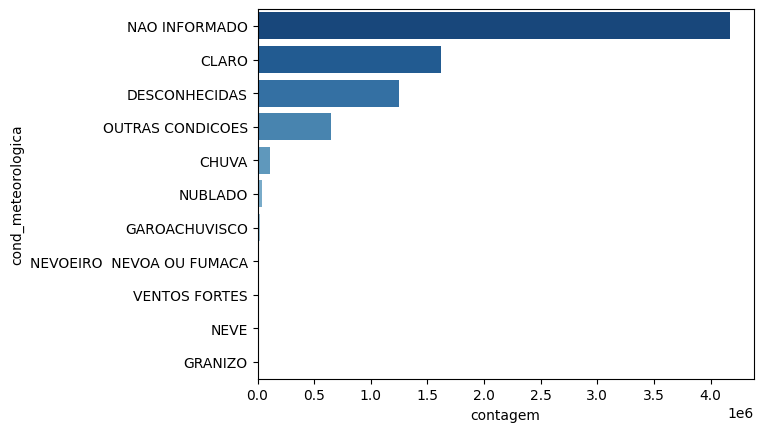

In [24]:
plot_count_col("./query-results/Contagem por Condição Meteorológica.csv", "contagem", "cond_meteorologica")

De fato existe o clima pesado não influência muito nos acidentes, mesmo com essa quantidade de dados não informados, analisando somente os a mostra, mão se tem tanta relevancia.

- **Contagem por Fase do Dia**

    Será se a fase do dia influência nos acidentes?

    Query:
    ```sql
    SELECT fase_dia, COUNT(*) as contagem
    FROM "renasest"."acidentes_gold"
    GROUP BY fase_dia
    ORDER BY contagem DESC;
    
    
    ```

    Resultado:
  

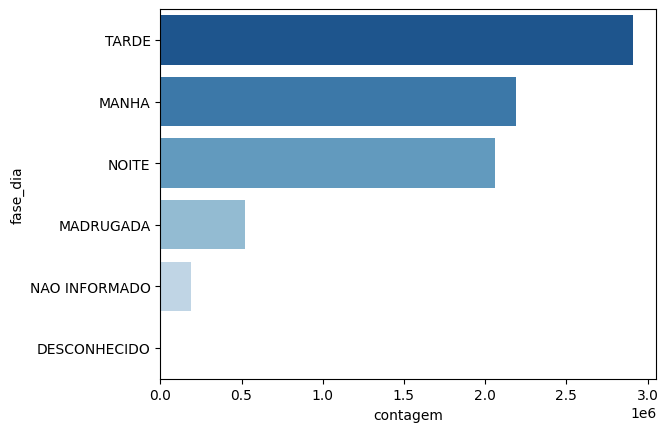

In [25]:
plot_count_col("./query-results/Contagem por Fase do Dia.csv", "contagem", "fase_dia")

De fato acidentes ocorrem mais durante a tarde, isso pode ter correlação com os picos de saída do trabalho.

- **Contagem por Dia da Semana**

    Será se os dias da semana influências nos acidentes?

    Query:
    ```sql
    SELECT dia_semana, COUNT(*) as contagem
    FROM "renasest"."acidentes_gold"
    GROUP BY dia_semana
    ORDER BY contagem DESC;
        
    
    ```

    Resultado:
  

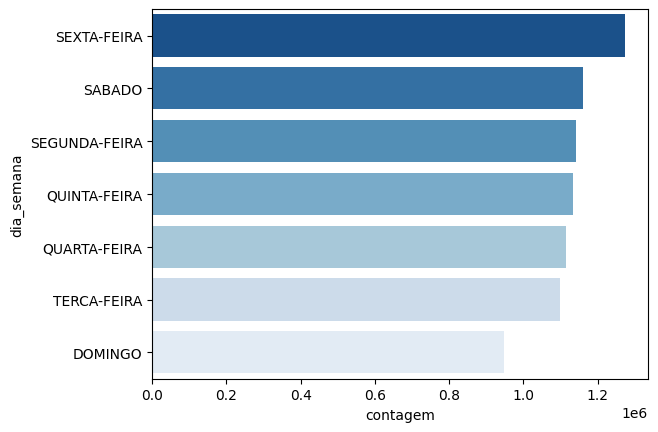

In [26]:
plot_count_col("./query-results/Contagem por Dia da Semana.csv", "contagem", "dia_semana")

De fato nas sextas feiras ocorrem mais acidentes, que podem ter correlação com as viagens de final de semana.

### Análise das vítimas por genero

Quem será que é mais sofre com acidentes no trânsito, homens ou mulheres?

- **Total de Vítimas**

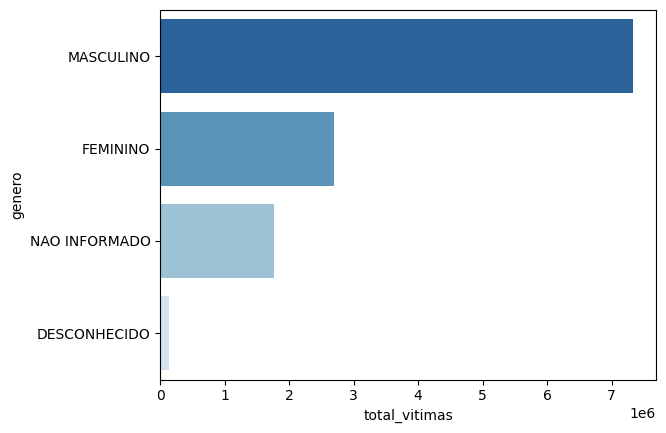

In [27]:
plot_count_col("./query-results/Contagem por Genero.csv", "total_vitimas", "genero")

- **Total de Mortos**

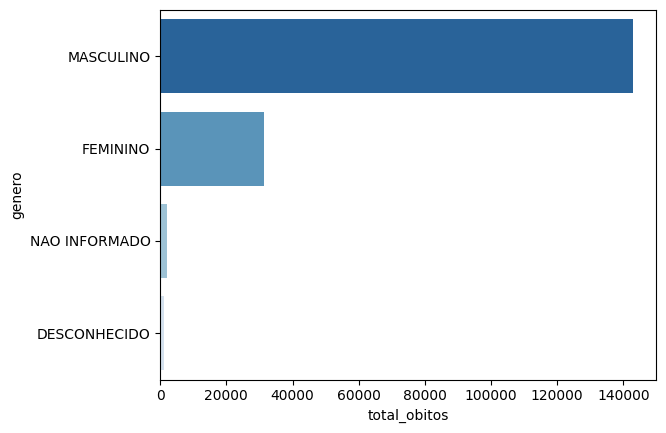

In [28]:
plot_count_col("./query-results/Contagem por Genero.csv", "total_obitos", "genero")

Homens tem uma maior chance de sofrerem acidentes e morrerem nessas ocorrências, que de fato podem esta relacionado com a maior quantidade de homens  no trânsito do que em relação a mulheres.

### Análise da Tabela Temporal por Genero
Essa tabela foi gerada pelo sequinte query:

```sql
SELECT 
    a.dia_semana, 
    v.genero, 
    SUM(v.qtde_obitos) as total_mortos
FROM "renasest"."acidentes_gold" a
JOIN "renasest"."vitimas_gold" v ON a.num_acidente = v.num_acidente
WHERE v.genero IN ('MASCULINO', 'FEMININO')
GROUP BY a.dia_semana, v.genero;
```

### Análise da Tabela Mortos Durante a Semana Por Fase do Dia

Como que ocorre os acidentes durenate a semana em relação com a fase do dia?

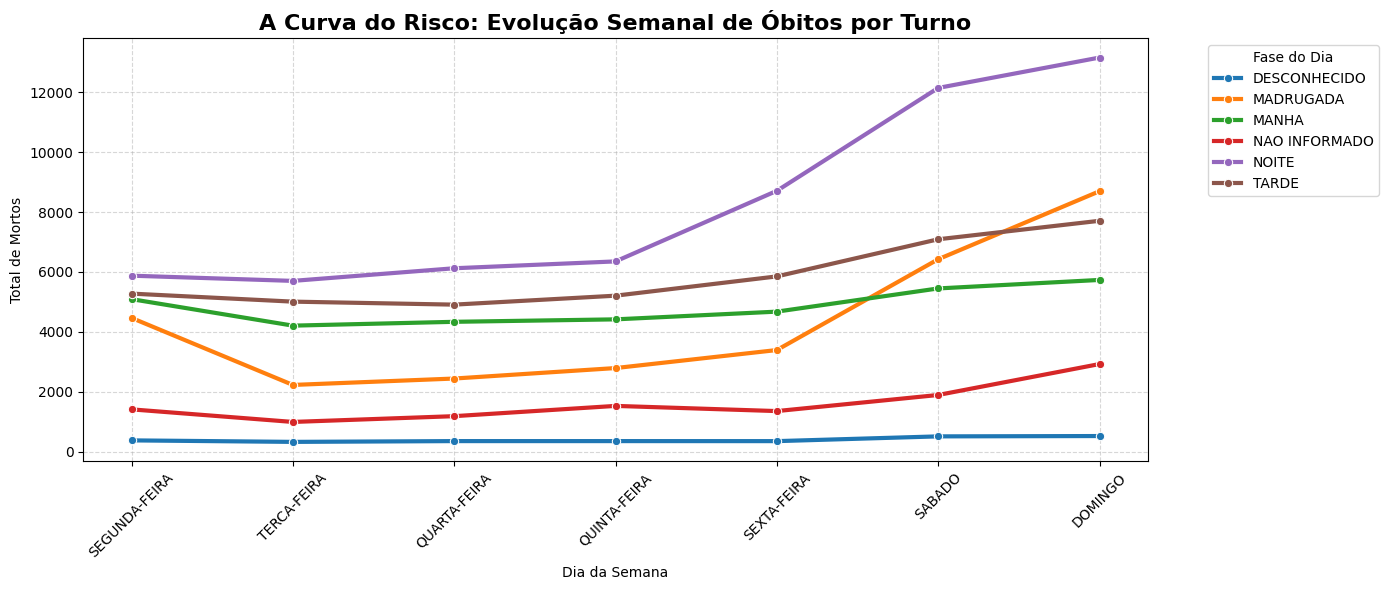

In [29]:
analise_mortos_semana()

Vemos que de madrugada é o turno mais seguro para se viajar, e de noite é o pior, durante a semana. Mas em relação com o final de semana, a melhor escolha é pela manhã.

### Análise da Tabela Mortos Durante a Semana Por Genero

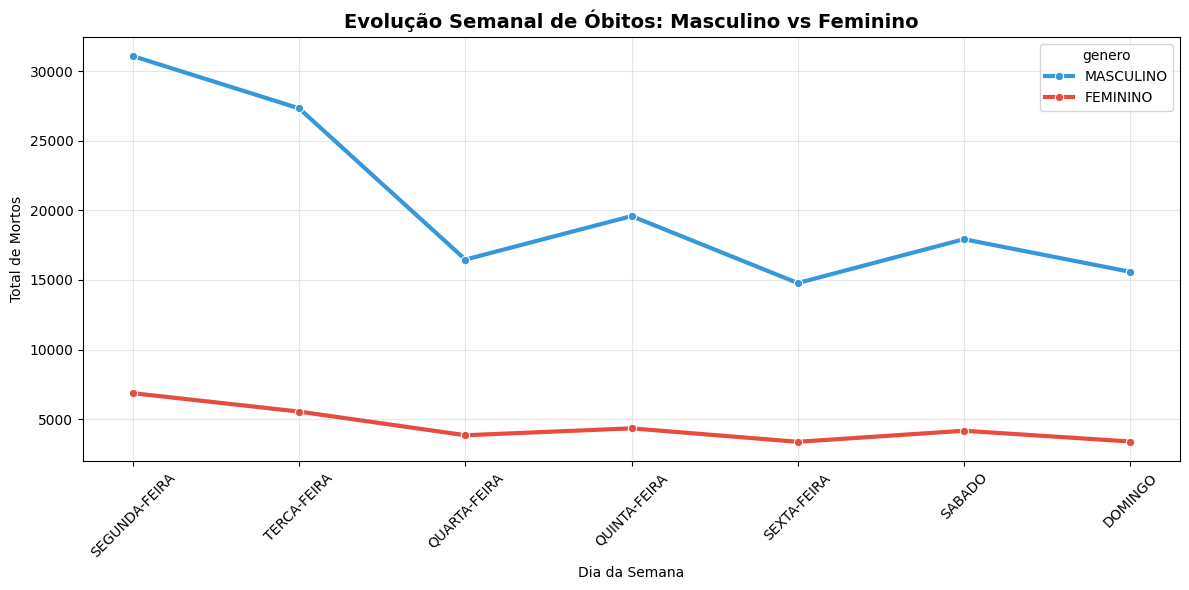

In [30]:
analise_mortos_genero()

Vemos que a quatidade de homens mortos em acidentes é muito maior que a de mulheres.

# Conclusão

Essas foram algumas análises extraídas da base de dados do RENASEST e filtradas usando AWS.

Alguns insights interessantes:
- o clima não tem grande influência nos acidentes
- Acidentes ocorrem maior parte durante o dia, com seu pico a tarde
- Na semana, acidentes são mais recorrentes na sexta-feira
- Na semana, acidentes ocorrem menos no domingo
- Homens morrem mais que mulheres em acidentes nas estradas
- A quantidade de mortos cresce durante a semana com seu pico aos domingos e de noite
- Segunda é o dia da semana que mais morre pessoas no transito, principalmente homens

**Temos em mente que mesmo com maiores quantidades de acidentes em determinado dia, não implica que haverá mais mortos para esse dia, que as mortes estão relacionadas com outros fatores, como segundas e sextas onde se tem relação com pessoas tendem a viajar mais nos finais de semana. Também, pode se dizer que os picos de acindetes na parte da tarde, demonstra maior numeros de veiculos de transporte no final do turno de trabalho, aumentando a maior chance de ocorrencias.**

**Portanto, escolham sempre viajar durante a semana as madrugadas e nos finais de semana as manhãs.**

